# Import libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.model_selection import train_test_split,cross_val_score,StratifiedKFold
from xgboost import XGBClassifier
import optuna
from optuna.pruners import MedianPruner

# Import Data

In [10]:
cols=['Length','Width','Size','Conc','Conc1','Asym','M3Long','M3Trans','Alpha','Dist','Class']
df=pd.read_csv('magic04.data',names=cols)

In [11]:
print(df.head(5))

     Length     Width    Size    Conc   Conc1      Asym   M3Long  M3Trans  \
0   28.7967   16.0021  2.6449  0.3918  0.1982   27.7004  22.0110  -8.2027   
1   31.6036   11.7235  2.5185  0.5303  0.3773   26.2722  23.8238  -9.9574   
2  162.0520  136.0310  4.0612  0.0374  0.0187  116.7410 -64.8580 -45.2160   
3   23.8172    9.5728  2.3385  0.6147  0.3922   27.2107  -6.4633  -7.1513   
4   75.1362   30.9205  3.1611  0.3168  0.1832   -5.5277  28.5525  21.8393   

     Alpha      Dist Class  
0  40.0920   81.8828     g  
1   6.3609  205.2610     g  
2  76.9600  256.7880     g  
3  10.4490  116.7370     g  
4   4.6480  356.4620     g  


In [12]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19020 entries, 0 to 19019
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Length   19020 non-null  float64
 1   Width    19020 non-null  float64
 2   Size     19020 non-null  float64
 3   Conc     19020 non-null  float64
 4   Conc1    19020 non-null  float64
 5   Asym     19020 non-null  float64
 6   M3Long   19020 non-null  float64
 7   M3Trans  19020 non-null  float64
 8   Alpha    19020 non-null  float64
 9   Dist     19020 non-null  float64
 10  Class    19020 non-null  object 
dtypes: float64(10), object(1)
memory usage: 1.6+ MB
None


In [13]:
print(df.describe())

             Length         Width          Size          Conc         Conc1  \
count  19020.000000  19020.000000  19020.000000  19020.000000  19020.000000   
mean      53.250154     22.180966      2.825017      0.380327      0.214657   
std       42.364855     18.346056      0.472599      0.182813      0.110511   
min        4.283500      0.000000      1.941300      0.013100      0.000300   
25%       24.336000     11.863800      2.477100      0.235800      0.128475   
50%       37.147700     17.139900      2.739600      0.354150      0.196500   
75%       70.122175     24.739475      3.101600      0.503700      0.285225   
max      334.177000    256.382000      5.323300      0.893000      0.675200   

               Asym        M3Long       M3Trans         Alpha          Dist  
count  19020.000000  19020.000000  19020.000000  19020.000000  19020.000000  
mean      -4.331745     10.545545      0.249726     27.645707    193.818026  
std       59.206062     51.000118     20.827439     26

# Check for data imbalance

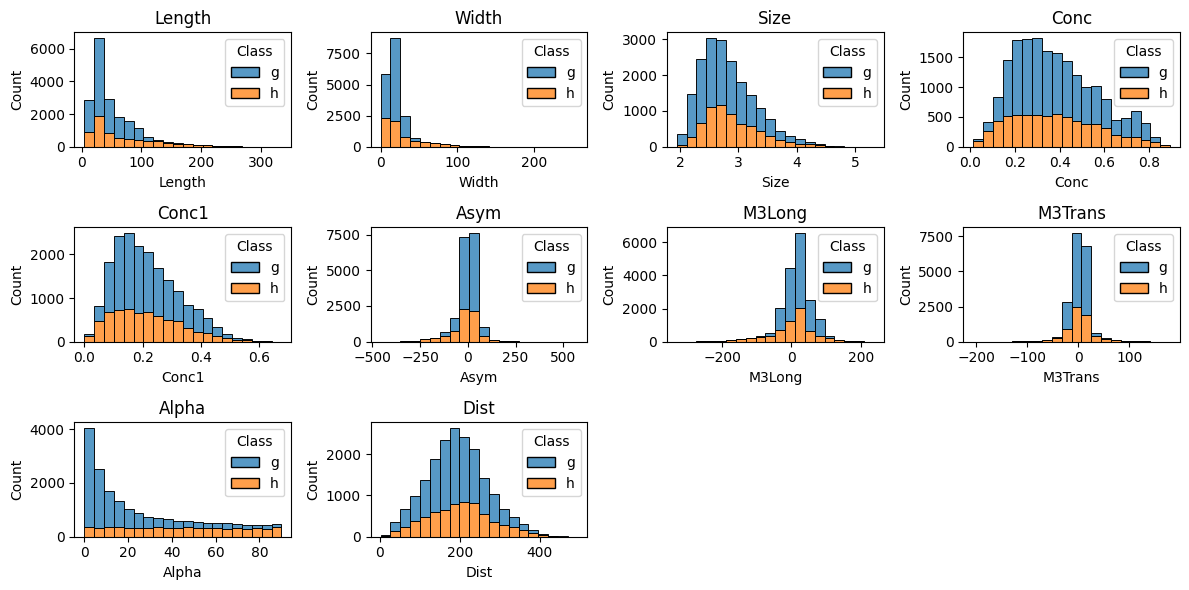

In [15]:
plt.figure(figsize=(12,6))
for i,label in enumerate(df.columns[:-1]):
     plt.subplot(3,4,i+1)
     sns.histplot(data=df, x=label, hue='Class', multiple='stack', bins=20)
     plt.title(label)
plt.tight_layout()
plt.show()

In [201]:
print(df.groupby("Class")["Class"].count())
# Slightly imbalanced

Class
g    12332
h     6688
Name: Class, dtype: int64


In [203]:
df["Class"]=(df["Class"]=="h").astype(int)

X=df.drop("Class",axis=1)
y=df["Class"]

In [205]:
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.8,random_state=44)

# Oputna

In [224]:
def objective(trial):
    param = {
        'verbosity': 0,
        'objective': 'binary:logistic',
        'eval_metric': 'aucpr',
        'booster': 'gbtree',
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight': 1.844
    }

    model = XGBClassifier(**param, use_label_encoder=False)

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='roc_auc')
    return np.mean(scores)

In [226]:
sampler=optuna.samplers.TPESampler()
pruner=MedianPruner(n_startup_trials=5,n_warmup_steps=10)
study=optuna.create_study(direction="maximize",sampler=sampler,pruner=pruner)
study.optimize(objective,n_trials=30,n_jobs=-1)
print(study.best_params)

[I 2025-05-14 10:01:18,240] A new study created in memory with name: no-name-95d14770-4d7d-40ac-b86d-dc3a6f8a3b92
[I 2025-05-14 10:01:31,465] Trial 5 finished with value: 0.8891877104921008 and parameters: {'max_depth': 3, 'learning_rate': 0.0020852640525308294, 'n_estimators': 478, 'gamma': 2.3254056642668663, 'min_child_weight': 10, 'subsample': 0.8040899707878663, 'colsample_bytree': 0.6185419522594586, 'reg_alpha': 0.012830286981599113, 'reg_lambda': 6.660685893836081e-06}. Best is trial 5 with value: 0.8891877104921008.
[I 2025-05-14 10:01:31,570] Trial 1 finished with value: 0.9330492847670119 and parameters: {'max_depth': 6, 'learning_rate': 0.06185346101141302, 'n_estimators': 359, 'gamma': 2.9430949573772187, 'min_child_weight': 5, 'subsample': 0.742839342446227, 'colsample_bytree': 0.7289077897099688, 'reg_alpha': 1.613602314695263e-07, 'reg_lambda': 5.122480148401207}. Best is trial 1 with value: 0.9330492847670119.
[I 2025-05-14 10:01:35,687] Trial 2 finished with value: 0.

{'max_depth': 5, 'learning_rate': 0.05212382457864226, 'n_estimators': 987, 'gamma': 3.267575979469738, 'min_child_weight': 5, 'subsample': 0.6949957618678404, 'colsample_bytree': 0.7571011773990171, 'reg_alpha': 1.213688761025363e-08, 'reg_lambda': 1.6854880993894007e-08}


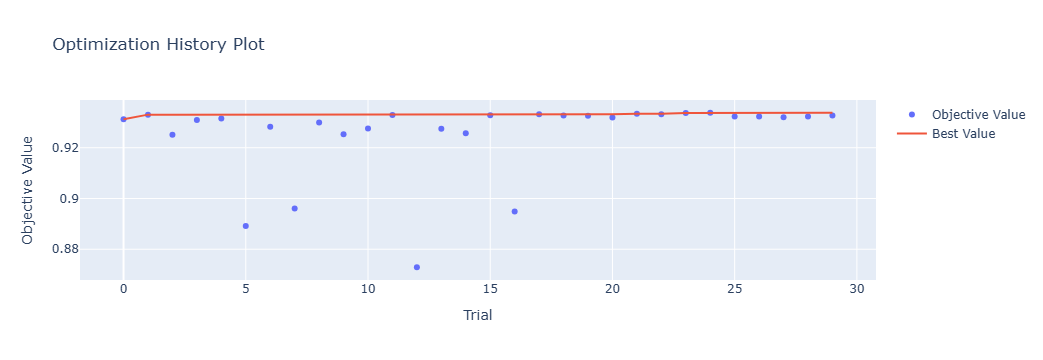

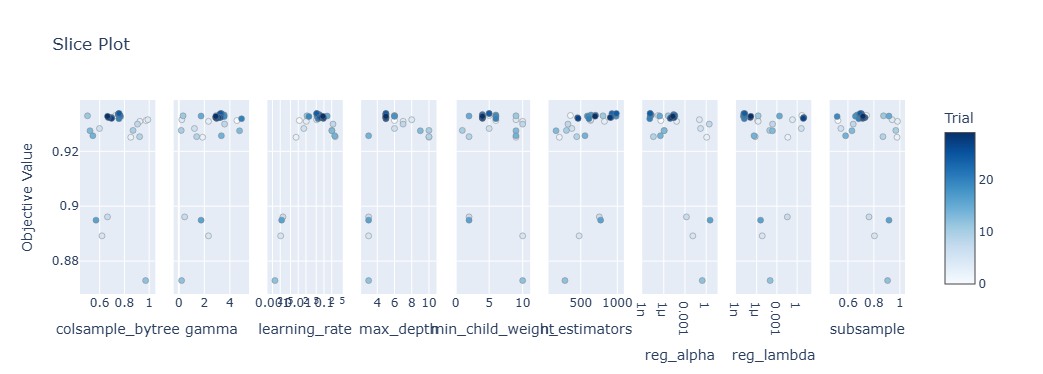

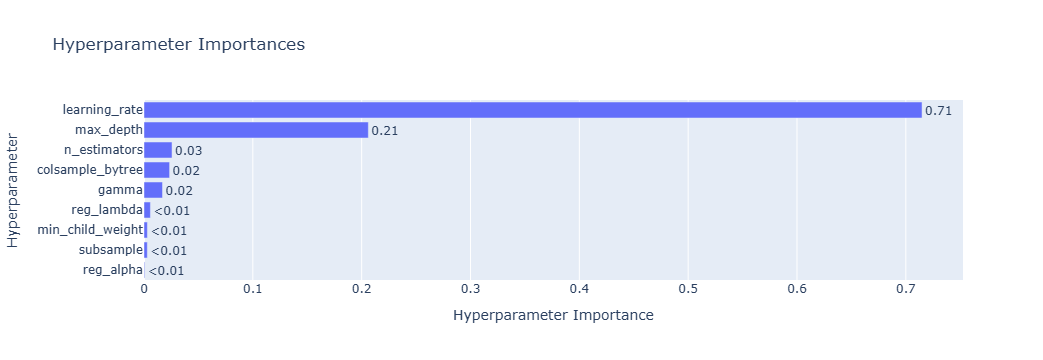

In [228]:
optuna.visualization.plot_optimization_history(study).show()
optuna.visualization.plot_slice(study).show()
optuna.visualization.plot_param_importances(study).show()

In [230]:
XGB=XGBClassifier(**study.best_params)
XGB.fit(X_train,y_train)
y_pred=XGB.predict(X_test)

In [231]:
cr=classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.88      0.95      0.91      2419
           1       0.89      0.77      0.83      1385

    accuracy                           0.88      3804
   macro avg       0.89      0.86      0.87      3804
weighted avg       0.88      0.88      0.88      3804



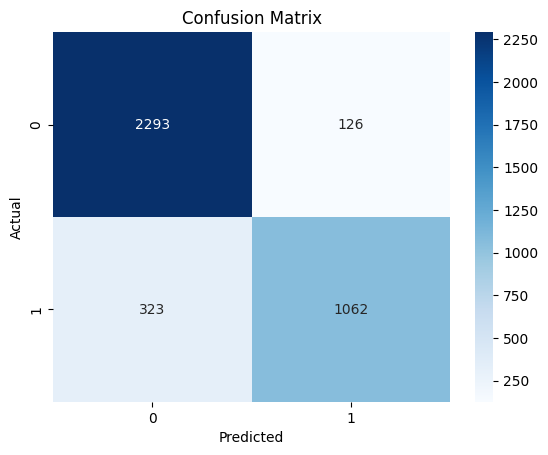

In [236]:
sns.heatmap(confusion_matrix(y_test,y_pred),cmap="Blues",fmt="d",annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()